# Linear regression

### $y_{pred} = \theta_{0} + \theta_{1}x_{1} + .....+ \theta_{n}x_{n} $
### to train a linear model you need to find the value of $\theta$ that minimizes the RMSE or MSE, for m instances. 
### MSE = $1/m  \sum_{i} (\theta^{T}x^{i}-y^{i})^{2} $

In [36]:
import matplotlib as mpl
import matplotlib.pyplot as plt

In [37]:
import numpy as np
size = 100
# lets create some look looking linear data
X = 2 * np.random.rand(size, 1)
y = 4 + 3 * X + np.random.randn(size, 1)
# lets compute the best value of PARAMETER using the normal equation
X_b = np.c_[np.ones((size,1)), X]
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
print(f"Input Matrix Dim = {X.shape}\n")
print(f"Output Matrix Dim= {X_b.shape}\n")
print(f"Best parameters = {theta_best}")


Input Matrix Dim = (100, 1)

Output Matrix Dim= (100, 2)

Best parameters = [[3.84844551]
 [3.25807915]]


(2, 1)
Shape predicted matrix = (2, 2)
predicted values = [[ 3.84844551]
 [10.36460382]]


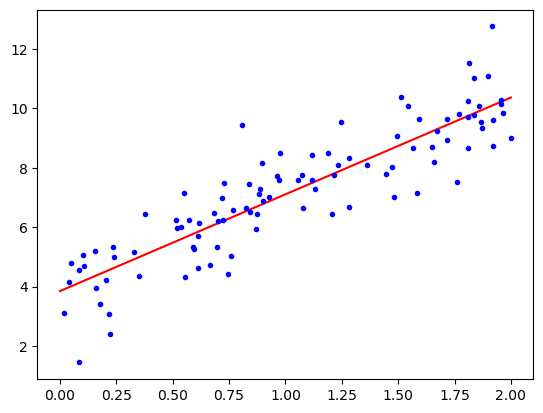

In [38]:
# lets make some prediction

X_new = np.array([[0], [2]])
print(X_new.shape)

# add the bias term
X_new_b = np.c_[np.ones((2,1)), X_new]
print(f"Shape predicted matrix = {X_new_b.shape}")
y_predict = X_new_b.dot(theta_best)
print(f"predicted values = {y_predict}")

plt.plot(X_new, y_predict, "r-")
plt.plot(X, y, "b.")
plt.show()

In [39]:
# lets do something similar using Scikit-Learn
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X,y)
par0, par1 = lin_reg.intercept_, lin_reg.coef_
print(f"Best parameters values = {par0, par1}")
predicted_values = lin_reg.predict(X_new)
print(f"Predicted values = {predicted_values}")

Best parameters values = (array([3.84844551]), array([[3.25807915]]))
Predicted values = [[ 3.84844551]
 [10.36460382]]


# Gradient Descent

## idea: tweak parameters ITERATIVELY in order to minimize a cost function
### Implementation: calculate the gradient of the error function with regards of parameter vector, and it goes in the direction of descending gradient.
### Parameter of gradient descent: learning rate (size of the steps)

## Batch gradient descent
### $\theta^{(next step)} = \theta - \eta\nabla_{\theta} MSE(\theta) $

In [ ]:
# lets look an example
eta = 0.1
n_iterations = 1000
m = 100

theta = np.random.randn(2,1)
print(theta.shape)

for iteration in range(n_iterations):
    gradients = 2/m*X_b.T.dot(X_b.dot(theta)-y)
    theta = theta - eta*gradients

print(f"results = {theta}")

(2, 1)
results = [[3.84844551]
 [3.25807915]]


## Stochastic Gradient 
### idea: pick at random instance in the training set at every step and computes the gradients based only on that single instance
### learning schedule = reduce the learning rate at each step 

In [41]:
n_epochs = 50
t0, t1 = 5, 50

def learning_schedule(t):
    return t0/(t + t1)

theta = np.random.randn(2,1)

for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * m + i)
        theta = theta - eta * gradients

print(f"Predicted parameters = {theta}")



Predicted parameters = [[3.81471382]
 [3.22557809]]


In [43]:
# lets use SGD with sklearn
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1)
sgd_reg.fit(X, y.ravel())
sgd_reg.intercept_, sgd_reg.coef_

(array([3.8863066]), array([3.31716301]))

# Exercises 

# What Linear Regression training algorithm can you use if you have a training set with millions of features
## Stochastic gradient descendent (SGD)

# Suppose the features in your training set have very different scales. What algorithms might suffer from this, and how? What can you do about it?
## In general SGD, normalize all features using Scikit-Learn

